### Wczytanie i wstępna inspekcja danych


In [ ]:
import pandas as pd
import re
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

path = "/content/drive/MyDrive/pracaDyplomowa/gp_practice_population_demographics.xlsx"
df = pd.read_excel(path,sheet_name='data')
print("shape: ",df.shape)
print("Dtypes: ",df.dtypes)
print(df.head(5))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
shape:  (83391, 23)
Dtypes:  Date            datetime64[ns]
PracticeCode             int64
HB                      object
HSCP                    object
Sex                     object
SexQF                   object
AllAges                float64
Ages0to4               float64
Ages0To4QF              object
Ages5to14              float64
Ages5To14QF             object
Ages15to24             float64
Ages15To24QF            object
Ages25to44             float64
Ages25To44QF            object
Ages45to64             float64
Ages45To64QF            object
Ages65to74             float64
Ages65To74QF            object
Ages75to84             float64
Ages75To84QF            object
Ages85plus             float64
Ages85PlusQF            object
dtype: object
        Date  PracticeCode         HB       HSCP     Sex SexQF  AllAges  \
0 2014-01-01         10002  S08000030  S

Zbiór danych zawiera 83 391 obserwacji i 23 zmienne.

Zmienna `Date` ma poprawny typ datetime, natomiast zmienne demograficzne są zapisane jako wartości liczbowe (float64). Kolumny z sufiksem „QF” mają typ tekstowy i zawierają informacje jakościowe.

Struktura danych wskazuje na panelowy charakter zbioru (praktyka × data × płeć), co umożliwia analizę zmian w czasie oraz różnic regionalnych.

### Analiza braków danych i duplikatów


In [ ]:
missing_values = (df.isna().mean() * 100).sort_values(ascending=False)
print("Top missing columns (%): ")
print(missing_values)


duplicate_rows = df.duplicated().sum()
print("duplicated rows: ",duplicate_rows)

Top missing columns (%): 
Ages65To74QF    99.088631
Ages85PlusQF    99.088631
Ages75To84QF    99.088631
Ages15To24QF    99.088631
Ages25To44QF    99.088631
Ages5To14QF     99.088631
Ages0To4QF      99.088631
Ages45To64QF    99.088631
SexQF           66.663069
Ages25to44       0.143900
Ages15to24       0.143900
Ages65to74       0.143900
Ages45to64       0.143900
Ages0to4         0.143900
Ages5to14        0.143900
Ages75to84       0.143900
Ages85plus       0.143900
AllAges          0.019187
HSCP             0.000000
Date             0.000000
Sex              0.000000
PracticeCode     0.000000
HB               0.000000
dtype: float64
duplicated rows:  0


Kolumny z sufiksem „QF” zawierają niemal wyłącznie braki (ok. 99%), co wskazuje, że są to pola jakościowe i nie będą wykorzystywane w analizie ilościowej.

Zmienne demograficzne (liczebności grup wiekowych) mają znikomy poziom braków (<0.2%), co świadczy o wysokiej kompletności danych.

Nie wykryto duplikatów obserwacji.

Ogólnie jakość danych ilościowych należy ocenić jako bardzo dobrą, a ewentualne czyszczenie będzie ograniczone do usunięcia kolumn pomocniczych (QF).

### Zakres czasowy i struktura danych


In [ ]:
df["Date"] = pd.to_datetime(df["Date"])
print("Min date: ",df["Date"].min())
print("Max date: ",df["Date"].max())

if "PracticeCode" in df.columns:
    print("Unique practices:", df["PracticeCode"].nunique())

for col in ["Sex", "HB", "HSCP"]:
    if col in df.columns:
        print(col, "unique:", df[col].nunique())

Min date:  2014-01-01 00:00:00
Max date:  2021-07-01 00:00:00
Unique practices: 1082
Sex unique: 3
HB unique: 16
HSCP unique: 33


Dane obejmują okres od stycznia 2014 do lipca 2021, co umożliwia analizę długookresowych trendów.

Zidentyfikowano 1082 unikalne praktyki GP, co wskazuje na pełne pokrycie systemu podstawowej opieki zdrowotnej w Szkocji.

Struktura administracyjna obejmuje:
- 16 Health Boards (HB),
- 33 jednostki HSCP.

Zmienna płeć zawiera trzy kategorie (Female, Male, All), co potwierdza obecność danych zagregowanych oraz rozbicia według płci.

### Analiza zmian liczby pacjentów w czasie (wg płci)


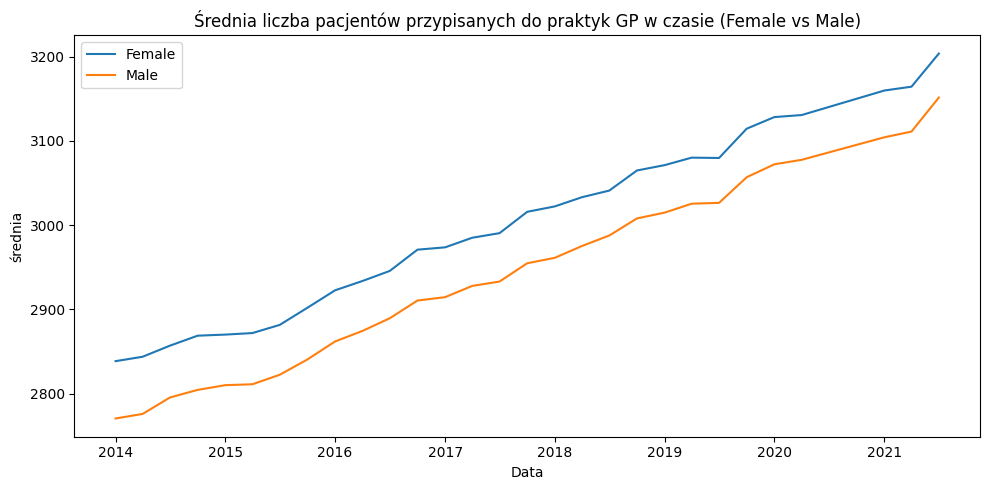

In [ ]:
col = "AllAges"
tmp = df.copy()
tmp = tmp.dropna(subset=[col])

ts = tmp.groupby(["Date", "Sex"])[col].mean().reset_index()

plt.figure(figsize=(10, 5))

for sex in ["Female", "Male"]:
    sub = ts[ts["Sex"] == sex]
    plt.plot(sub["Date"], sub[col], label=sex)

plt.title("Średnia liczba pacjentów przypisanych do praktyk GP w czasie (Female vs Male)")
plt.xlabel("Data")
plt.ylabel("średnia")
plt.legend()
plt.tight_layout()
plt.show()

W analizowanym okresie (2014–2021) obserwowany jest systematyczny wzrost średniej liczby pacjentów przypisanych do praktyk GP zarówno dla kobiet, jak i mężczyzn.

Liczba kobiet pozostaje nieznacznie wyższa niż liczba mężczyzn w całym okresie.

Trend ma charakter rosnący i relatywnie stabilny, bez wyraźnych załamań strukturalnych.

### Rozdzielenie danych zagregowanych i danych według płci


In [ ]:
df_mf = df[df["Sex"].isin(["Male","Female"])].copy()
df_all = df[df["Sex"] == "All"].copy()

print(df_mf.shape)
print(df_all.shape)

(55591, 23)
(27800, 23)


### Weryfikacja kompletności kategorii płci


In [ ]:
key = ["Date","PracticeCode"]
sex_sets = df.groupby(key)["Sex"].apply(lambda s:set(s)).reset_index(name="sex_set")
bad = sex_sets[sex_sets["sex_set"] != {"Male","Female","All"}]
print(f"Niepełny zestaw Sex (Date,PracticeCode): {len(bad)}")
print(bad.head(10))


Niepełny zestaw Sex (Date,PracticeCode): 9
            Date  PracticeCode        sex_set
182   2014-01-01         22033    {All, Male}
709   2014-01-01         65931    {All, Male}
1177  2014-04-01         22033    {All, Male}
1701  2014-04-01         65931    {All, Male}
4446  2015-01-01         49431  {Female, All}
13873 2017-07-01         22033    {All, Male}
14830 2017-10-01         22033    {All, Male}
15785 2018-01-01         22033    {All, Male}
16738 2018-04-01         22033    {All, Male}


Zidentyfikowano 9 przypadków, w których zestaw kategorii płci jest niepełny (najczęściej brak kategorii Female).
Liczba ta jest mała względem całego zbioru danych (83 tys. obserwacji).

### Zależność między wielkością praktyki a udziałem populacji 65+


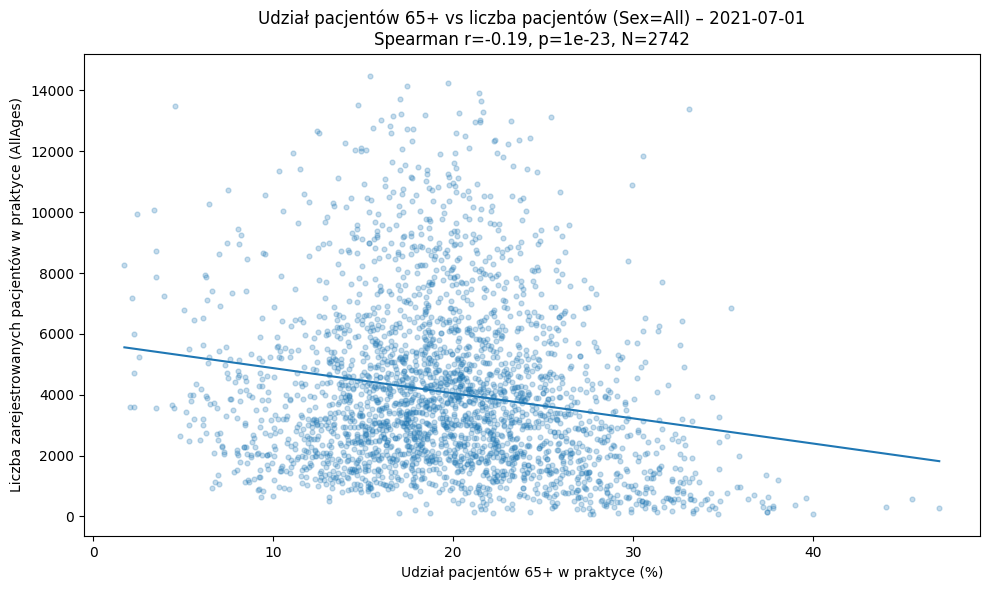

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

TRIM_Q = 0.99

copy = df.copy()
copy["Date"] = pd.to_datetime(copy["Date"])

copy = copy[copy["Sex"] == 'All'].copy()

snap_date = copy["Date"].max()
snap = df[df["Date"] == snap_date].copy()

age_65plus_cols = ["Ages65to74", "Ages75to84", "Ages85plus"]

snap = snap.dropna(subset=["AllAges"] + age_65plus_cols)

snap["share_65plus"] = (snap[age_65plus_cols].sum(axis=1) / snap["AllAges"]) * 100

snap["AllAges"] = pd.to_numeric(snap["AllAges"], errors="coerce")
snap = snap.dropna(subset=["share_65plus", "AllAges"])

y_max = snap["AllAges"].quantile(TRIM_Q)
snap_plot = snap[snap["AllAges"] <= y_max].copy()


x = snap_plot["share_65plus"].to_numpy()
y = snap_plot["AllAges"].to_numpy()


r, p = spearmanr(snap["share_65plus"], snap["AllAges"])
n = snap.shape[0]

m, b = np.polyfit(x, y, 1) if len(x) > 1 else (np.nan, np.nan)
xs = np.linspace(np.nanmin(x), np.nanmax(x), 200)

plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.25, s=12)

if len(x) > 1:
    plt.plot(xs, m * xs + b)

title_main = f"Udział pacjentów 65+ vs liczba pacjentów (Sex=All) – {snap_date.date()}"
title_stats = f"Spearman r={r:.2f}, p={p:.3g}, N={n}"
plt.title(title_main + "\n" + title_stats)

plt.xlabel("Udział pacjentów 65+ w praktyce (%)")
plt.ylabel("Liczba zarejestrowanych pacjentów w praktyce (AllAges)")



plt.tight_layout()
plt.show()

Zaobserwowano istotną statystycznie, lecz słabą ujemną korelację między wielkością praktyki a udziałem pacjentów 65+.

Oznacza to, że mniejsze praktyki mają tendencję do obsługi populacji o wyższym udziale osób starszych, natomiast większe praktyki częściej charakteryzują się młodszą strukturą demograficzną.

### Statystyki opisowe liczby pacjentów w praktykach GP


In [ ]:
df_all["AllAges"].describe()

,AllAges
count,27800.000000
mean,5931.153957
std,3720.676061
min,0.000000
25%,3173.000000
50%,5494.500000
75%,8180.250000
max,48657.000000


Średnia liczba pacjentów w praktyce wynosi około 5,9 tys., a mediana około 5,5 tys., co oznacza, że rozkład jest lekko prawostronnie skośny (część praktyk jest wyraźnie większa od typowej).

Połowa praktyk mieści się w przedziale od około 3,2 tys. do 8,2 tys. pacjentów, co pokazuje duże zróżnicowanie ich wielkości.

Maksymalna wartość (48,7 tys.) wskazuje, że w zbiorze znajdują się bardzo duże jednostki, które odstają od większości obserwacji.

W praktyce oznacza to, że wielkość praktyk jest mocno zróżnicowana i przy dalszym modelowaniu należy uwzględnić możliwość wpływu wartości skrajnych (np. poprzez transformację zmiennej lub ograniczenie outlierów).

### Rozkład liczby pacjentów w praktykach GP


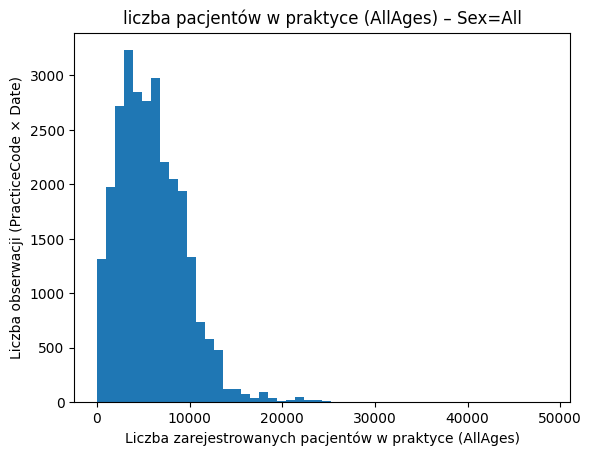

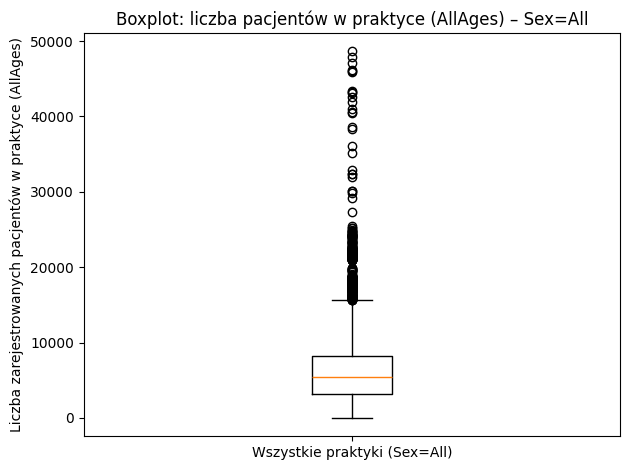

In [ ]:

x = df_all["AllAges"].dropna()

plt.figure()
plt.hist(x, bins=50)
plt.title("liczba pacjentów w praktyce (AllAges) – Sex=All")
plt.xlabel("Liczba zarejestrowanych pacjentów w praktyce (AllAges)")
plt.ylabel("Liczba obserwacji (PracticeCode × Date)")
plt.show()
print()
plt.figure()
plt.boxplot(x, vert=True)
plt.title("Boxplot: liczba pacjentów w praktyce (AllAges) – Sex=All")
plt.ylabel("Liczba zarejestrowanych pacjentów w praktyce (AllAges)")
plt.xticks([1], ["Wszystkie praktyki (Sex=All)"])
plt.tight_layout()
plt.show()


Histogram wskazuje na wyraźnie prawostronnie skośny rozkład liczby pacjentów – większość praktyk ma od kilku do około 10 tys. pacjentów, natomiast niewielka liczba jednostek osiąga znacznie większe wartości.

Boxplot potwierdza obecność licznych obserwacji skrajnych po stronie dużych praktyk. Mediana znajduje się wyraźnie poniżej wartości maksymalnych, co wskazuje na nierównomierną strukturę wielkości praktyk.

### Identyfikacja największych praktyk GP


In [ ]:
df_all.sort_values("AllAges", ascending=False)[["Date","PracticeCode","HB","HSCP","AllAges"]].head(10)


,Date,PracticeCode,HB,HSCP,AllAges
81792,2021-07-01,43576,S08000031,S37000034,48657.0
79023,2021-04-01,43576,S08000031,S37000034,47877.0
76248,2021-01-01,43576,S08000031,S37000034,47049.0
70665,2020-01-01,43576,S08000031,S37000034,46215.0
73461,2020-04-01,43576,S08000031,S37000034,46086.0
67866,2019-10-01,43576,S08000031,S37000034,45912.0
59406,2019-01-01,43576,S08000021,S37000034,43368.0
62232,2019-04-01,43576,S08000021,S37000034,43222.0
65055,2019-07-01,43576,S08000031,S37000034,43164.0
56574,2018-10-01,43576,S08000021,S37000034,42631.0


### Weryfikacja obserwacji z zerową liczbą pacjentów


In [ ]:
zero_cnt = (df_all["AllAges"] == 0).sum()
print("Liczba rekordów z AllAges = 0:", zero_cnt)
print("Procent:", round(100*zero_cnt/len(df_all), 3), "%")

df_all_nz = df_all[df_all["AllAges"] > 0].copy()
df_all_nz["AllAges"].describe()


Liczba rekordów z AllAges = 0: 2
Procent: 0.007 %


,AllAges
count,27798.000000
mean,5931.580689
std,3720.469742
min,1.000000
25%,3173.250000
50%,5495.500000
75%,8180.750000
max,48657.000000


Zidentyfikowano jedynie 2 obserwacje z wartością `AllAges = 0`, co stanowi 0,007% zbioru.

Odsetek ten jest pomijalny i nie wpływa istotnie na analizę. Po wykluczeniu tych rekordów podstawowe statystyki zmiennej `AllAges` pozostają praktycznie niezmienione.

### Rozkład obserwacji i wielkości praktyk w ujęciu regionalnym


In [ ]:
hb_counts = df_all_nz["HB"].value_counts().head(10)
print("Top 10 HB (liczba rekordów):")
print(hb_counts)

hscp_counts = df_all_nz["HSCP"].value_counts().head(10)
print("\nTop 10 HSCP (liczba rekordów):")
print(hscp_counts)

hb_mean = df_all_nz.groupby("HB")["AllAges"].mean().sort_values(ascending=False).head(10)
print("\nTop 10 HB (średnia AllAges):")
print(hb_mean)


Top 10 HB (liczba rekordów):
HB
S08000021    5326
S08000024    3563
S08000022    2856
S08000023    2376
S08000020    2168
S08000030    1880
S08000029    1651
S08000031    1646
S08000015    1614
S08000019    1600
Name: count, dtype: int64

Top 10 HSCP (liczba rekordów):
HSCP
S37000034    4245
S37000012    2125
S37000016    1905
S37000035    1615
S37000028    1471
S37000014    1270
S37000006     958
S37000004     951
S37000002     938
S37000001     852
Name: count, dtype: int64

Top 10 HB (średnia AllAges):
HB
S08000020    7967.052583
S08000024    7661.314903
S08000015    6922.607807
S08000032    6793.377465
S08000029    6707.261660
S08000030    6588.698936
S08000023    6275.421296
S08000019    5765.293125
S08000031    5599.240583
S08000021    5265.852234
Name: AllAges, dtype: float64


Liczba obserwacji różni się między regionami, co wynika z odmiennej liczby praktyk oraz okresów raportowania.

Występują wyraźne różnice w średniej liczbie pacjentów między Health Boards — niektóre regiony charakteryzują się systematycznie większymi praktykami.

Oznacza to, że wielkość praktyk nie jest jednorodna przestrzennie, co może mieć znaczenie przy modelowaniu zależności między strukturą demograficzną a obciążeniem systemu opieki zdrowotnej.

W dalszej analizie należy uwzględnić potencjalny efekt regionalny (np. poprzez kontrolę zmiennej HB).

### Przygotowanie zmiennych wiekowych do analizy korelacyjnej


In [ ]:


meta = {"Date","PracticeCode","HB","HSCP","Sex"}
age_cols = [c for c in df_all_nz.columns
            if c not in meta and not c.lower().endswith("qf")]

for c in age_cols:
    df_all_nz[c] = pd.to_numeric(df_all_nz[c], errors="coerce")

print("Liczba kolumn do korelacji:", len(age_cols))
age_cols


Liczba kolumn do korelacji: 9


['AllAges',
 'Ages0to4',
 'Ages5to14',
 'Ages15to24',
 'Ages25to44',
 'Ages45to64',
 'Ages65to74',
 'Ages75to84',
 'Ages85plus']

### Macierz korelacji między grupami wiekowymi


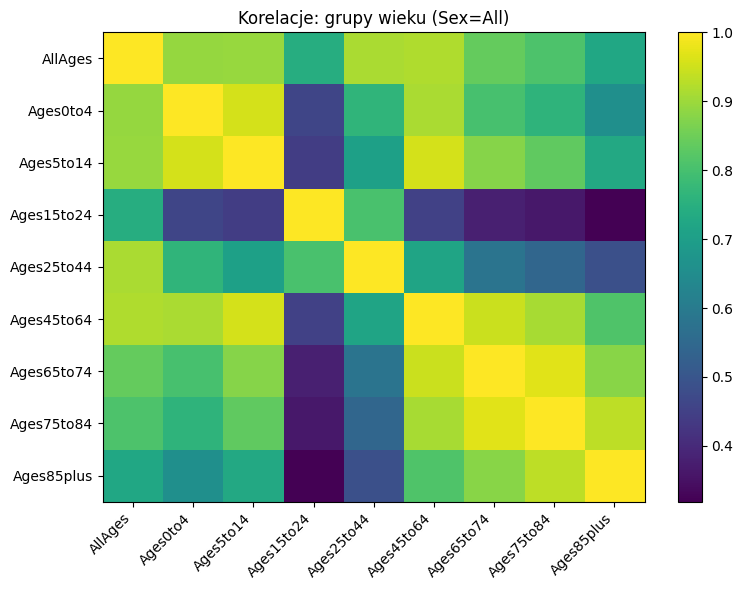

In [ ]:
corr = df_all_nz[age_cols].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, aspect="auto")
plt.colorbar()
plt.title("Korelacje: grupy wieku (Sex=All)")

plt.xticks(range(len(age_cols)), age_cols, rotation=45, ha="right")
plt.yticks(range(len(age_cols)), age_cols)

plt.tight_layout()
plt.show()

Zależności między sąsiednimi grupami wiekowymi są bardzo silne i dodatnie, co oznacza, że praktyki z większą liczbą pacjentów w jednej grupie wiekowej zwykle mają również większą liczbę pacjentów w grupach pokrewnych.

Najsilniejsze korelacje obserwowane są między grupami 65–74, 75–84 oraz 85+, co wskazuje na spójny blok populacji starszej.

Grupa 15–24 wykazuje relatywnie słabsze korelacje z populacją senioralną, co sugeruje częściowe zróżnicowanie struktury demograficznej między praktykami młodszymi i starszymi.

### Identyfikacja wartości odstających (metoda IQR)


In [ ]:
q1 = df_all_nz["AllAges"].quantile(0.25)
q3 = df_all_nz["AllAges"].quantile(0.75)
iqr = q3 - q1
low = q1 - 1.5*iqr
high = q3 + 1.5*iqr

outliers = df_all_nz[(df_all_nz["AllAges"] < low) | (df_all_nz["AllAges"] > high)]
print("Granice IQR:", low, high)
print("Liczba outlierów:", len(outliers))
outliers.sort_values("AllAges", ascending=False)[["Date","PracticeCode","HB","HSCP","AllAges"]].head(10)


Granice IQR: -4338.0 15692.0
Liczba outlierów: 375


,Date,PracticeCode,HB,HSCP,AllAges
81792,2021-07-01,43576,S08000031,S37000034,48657.0
79023,2021-04-01,43576,S08000031,S37000034,47877.0
76248,2021-01-01,43576,S08000031,S37000034,47049.0
70665,2020-01-01,43576,S08000031,S37000034,46215.0
73461,2020-04-01,43576,S08000031,S37000034,46086.0
67866,2019-10-01,43576,S08000031,S37000034,45912.0
59406,2019-01-01,43576,S08000021,S37000034,43368.0
62232,2019-04-01,43576,S08000021,S37000034,43222.0
65055,2019-07-01,43576,S08000031,S37000034,43164.0
56574,2018-10-01,43576,S08000021,S37000034,42631.0


Zidentyfikowano 375 obserwacji odstających, co stanowi niewielki odsetek zbioru.

Najwyższe wartości dotyczą tej samej dużej praktyki w kolejnych okresach, co potwierdza, że są to rzeczywiste, strukturalnie duże jednostki, a nie błędy danych.

## EDA danych tekstowych – przygotowanie środowiska i źródeł


In [ ]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pdfplumber

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk import bigrams

from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer

import gensim
from gensim import corpora
from gensim.models import LdaModel

nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)
STOPWORDS = set(stopwords.words("english"))
custom_stopwords = {
    "january","2025","2022","2019","2024",
    "bbc","news","report","reports","publication"
}
STOPWORDS = STOPWORDS.union(custom_stopwords)

PDF_PATHS = {
    "public_health_bulletin_2025_01": "/content/drive/MyDrive/pracaDyplomowa/ph-digest-jan-25.pdf",
    "gp_workforce_survey_2022": "/content/drive/MyDrive/pracaDyplomowa/gp_workforce_survey_2022_report.pdf",
}

### Ekstrakcja, normalizacja i tokenizacja tekstu


In [ ]:
def extract_text_pdf(pdf_path: str) -> str:
    text_parts = []
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            t = page.extract_text() or ""
            text_parts.append(t)
    return "\n".join(text_parts)

def normalize_text(text: str) -> str:
    text = text.replace("\u00ad", "")
    text = text.replace("￾", " ")
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def tokenize(text: str) -> list[str]:
    text = text.lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) >= 3]
    return tokens

### Ekstrakcja tekstu z raportów


In [ ]:
raw_texts = {}
for name, path in PDF_PATHS.items():
    raw = extract_text_pdf(path)
    raw_texts[name] = normalize_text(raw)

for k, v in raw_texts.items():
    print(k, "znaki:", len(v))

public_health_bulletin_2025_01 znaki: 16647
gp_workforce_survey_2022 znaki: 40785


### Podział raportów na sekcje (jednostki analizy)


In [ ]:
def split_into_sections(doc_name: str, text: str) -> list[dict]:
    patterns = [
        r"\bIntroduction\b",
        r"\bMain points\b",
        r"\bResults and commentary\b",
        r"\bAppendix\b",
        r"\bAlcohol\b",
        r"\bCancer\b",
        r"\bCovid\b",
        r"\bHealth & Social Care\b",
        r"\bHealth Protection\b",
        r"\bPopulation Statistics\b",
        r"\bOlder People\b",
        r"\bPublic Health\b",
        r"\bAccident and emergency\b",
    ]
    for p in patterns:
        text = re.sub(p, lambda m: "\n===SECTION=== " + m.group(0) + "\n", text, flags=re.IGNORECASE)

    chunks = [c.strip() for c in text.split("===SECTION===") if c.strip()]
    out = []
    for i, c in enumerate(chunks):
        out.append({
            "source": doc_name,
            "section_id": i,
            "text": c
        })
    return out

sections = []
for name, txt in raw_texts.items():
    sections.extend(split_into_sections(name, txt))

df_docs = pd.DataFrame(sections)
df_docs["n_chars"] = df_docs["text"].str.len()
df_docs = df_docs[df_docs["n_chars"] >= 800].reset_index(drop=True)
df_docs.head(), df_docs.shape

(                           source  section_id  \
 0  public_health_bulletin_2025_01           3   
 1  public_health_bulletin_2025_01          24   
 2  public_health_bulletin_2025_01          28   
 3  public_health_bulletin_2025_01          36   
 4  public_health_bulletin_2025_01          37   
 
                                                 text  n_chars  
 0  Public Health\n Reports Digest compiled by NHS...     1102  
 1  Public Health\n Scotland, 9th January 2025 “Tr...     1268  
 2  Public Health\n Scotland, 28 January 2025 “The...     1297  
 3  Public Health\n Scotland, 28 January 2025 “The...     1194  
 4  Public Health\n, 2025; Mental health trends am...     2152  ,
 (14, 4))

Utworzono zbiór sekcji `df_docs` zawierający pola: źródło (`source`), identyfikator sekcji (`section_id`) oraz treść (`text`). Dodatkowo policzono długość sekcji w znakach (`n_chars`).

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

### Tokenizacja tekstów i podstawowe statystyki korpusu


In [ ]:
df_docs["tokens"] = df_docs["text"].apply(tokenize)
df_docs["n_tokens"] = df_docs["tokens"].apply(len)

vocab = set(t for toks in df_docs["tokens"] for t in toks)

print("Liczba dokumentów:", len(df_docs))
print("Liczba unikalnych słów:", len(vocab))
print("Średnia długość dokumentu (w tokenach):", df_docs["n_tokens"].mean())
print("Mediana długości dokumentu (w tokenach):", df_docs["n_tokens"].median())

df_docs.groupby("source")[["n_chars","n_tokens"]].describe()

Liczba dokumentów: 14
Liczba unikalnych słów: 1127
Średnia długość dokumentu (w tokenach): 290.2857142857143
Mediana długości dokumentu (w tokenach): 114.0


n_chars                                    \
                                 count         mean          std     min   
source                                                                     
gp_workforce_survey_2022           8.0  4718.750000  7741.731271   898.0   
public_health_bulletin_2025_01     6.0  1453.166667   400.363044  1102.0   

                                                                 n_tokens  \
                                   25%     50%      75%      max    count   
source                                                                      
gp_workforce_survey_2022        1095.0  1616.0  3606.00  23602.0      8.0   
public_health_bulletin_2025_01  1212.5  1282.5  1603.75   2152.0      6.0   

                                                                             \
                                      mean         std   min     25%    50%   
source                                                                        
gp_workforce_survey_2022        410.000000  686.982637  84.0   87.50  135.5   
public_health_bulletin_2025_01  130.666667   40.888466  90.0  110.25  114.0   

                                                
                                   75%     max  
source                                          
gp_workforce_survey_2022        297.50  2087.0  
public_health_bulletin_2025_01  144.75   202.0

Korpus składa się z 14 sekcji tekstowych i zawiera 1127 unikalnych słów.

Średnia długość dokumentu wynosi ok. 290 tokenów, jednak mediana (114) jest wyraźnie niższa, co wskazuje na silną asymetrię rozkładu długości – część dokumentów jest znacznie dłuższa od pozostałych.

Raport „gp_workforce_survey_2022” zawiera dłuższe sekcje (średnio ok. 410 tokenów) niż „public_health_bulletin_2025_01” (ok. 131 tokenów), co oznacza istotną różnicę strukturalną między źródłami.

### Rozkład długości sekcji tekstowych


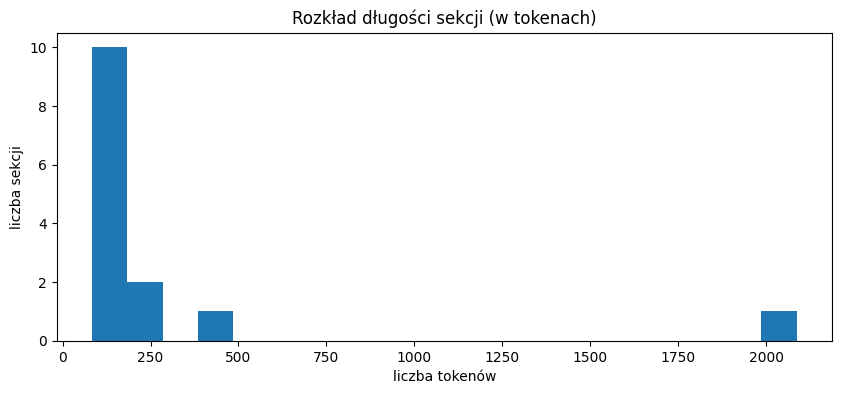

In [ ]:
plt.figure(figsize=(10,4))
plt.hist(df_docs["n_tokens"], bins=20)
plt.title("Rozkład długości sekcji (w tokenach)")
plt.xlabel("liczba tokenów")
plt.ylabel("liczba sekcji")
plt.show()

Większość sekcji ma stosunkowo niewielką długość (ok. 80–200 tokenów), natomiast pojedyncze dokumenty są znacznie dłuższe (kilkaset lub ponad 2000 tokenów).

Rozkład jest wyraźnie prawostronnie skośny, co potwierdza wcześniejszą różnicę między średnią a medianą długości dokumentów.

### Najczęściej występujące słowa


In [ ]:
all_tokens = [t for toks in df_docs["tokens"] for t in toks]
wc = Counter(all_tokens)

top = wc.most_common(25)
top_df = pd.DataFrame(top, columns=["token","count"])
top_df

,token,count
0,wte,130
1,headcount,93
2,estimated,91
3,data,83
4,nhs,57
5,practice,55
6,general,50
7,practices,50
8,nurse,50
9,survey,47


Najczęściej występujące słowa koncentrują się wokół tematyki zatrudnienia i organizacji pracy w ochronie zdrowia (np. „headcount”, „practice”, „nurse”, „sessions”, „hours”) oraz danych statystycznych („estimated”, „data”, „information”).

Obecność terminów takich jak „nhs”, „scotland”, „clinical” wskazuje na silny kontekst instytucjonalny i regionalny analizowanych raportów.

Wysoka pozycja skrótu „wte” (whole-time equivalent) potwierdza, że istotnym wątkiem dokumentów jest analiza zatrudnienia w przeliczeniu na pełne etaty.

### Wizualizacja najczęściej występujących słów


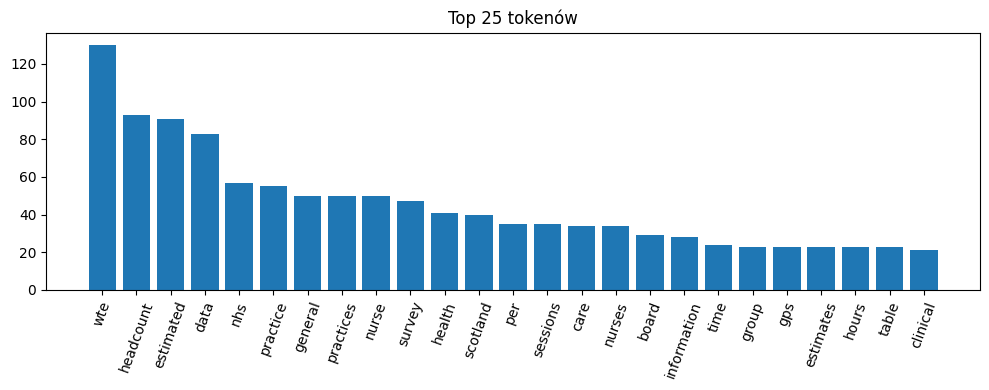

In [ ]:
plt.figure(figsize=(10,4))
plt.bar(top_df["token"], top_df["count"])
plt.xticks(rotation=70)
plt.title("Top 25 tokenów")
plt.tight_layout()
plt.show()

### Analiza najczęstszych bigramów


In [ ]:
all_bigrams = []
for toks in df_docs["tokens"]:
    all_bigrams.extend(list(bigrams(toks)))

bc = Counter(all_bigrams)
top_bi = bc.most_common(20)
top_bi_df = pd.DataFrame([(" ".join(k), v) for k, v in top_bi], columns=["bigram","count"])
top_bi_df

,bigram,count
0,estimated wte,41
1,general practice,34
2,nhs board,22
3,wte per,22
4,headcount estimated,18
5,headcount wte,15
6,estimated headcount,14
7,responding practices,14
8,primary care,13
9,practice nurse,13


Najczęstsze bigramy jednoznacznie wskazują na dominację tematyki zatrudnienia w podstawowej opiece zdrowotnej (np. „estimated wte”, „headcount wte”, „general practice”, „practice nurse”).

Widoczna jest również silna obecność kontekstu instytucjonalnego („nhs board”, „public health”, „practices scotland”) oraz odniesień metodologicznych („see methodology”, „methodology section”).

Analiza bigramów potwierdza, że dokumenty koncentrują się na raportowaniu zasobów kadrowych, przeliczeniach etatów oraz strukturze organizacyjnej systemu ochrony zdrowia.

### Analiza istotności terminów (TF-IDF)


In [ ]:
vectorizer = TfidfVectorizer(
    max_features=2000,
    stop_words="english",
    ngram_range=(1,2),
    min_df=1
)

X = vectorizer.fit_transform(df_docs["text"])
feature_names = np.array(vectorizer.get_feature_names_out())

scores = np.asarray(X.mean(axis=0)).ravel()
top_idx = scores.argsort()[::-1][:30]
tfidf_global = pd.DataFrame({"term": feature_names[top_idx], "mean_tfidf": scores[top_idx]})
tfidf_global

,term,mean_tfidf
0,gp,0.105751
1,wte,0.086105
2,data,0.078821
3,2025,0.071957
4,headcount,0.063952
5,health,0.060942
6,january 2025,0.059734
7,practice,0.057003
8,january,0.055434
9,estimated,0.054491


Najwyższe wartości TF-IDF uzyskały terminy związane z podstawową opieką zdrowotną i zatrudnieniem („gp”, „wte”, „headcount”, „workforce”, „survey”), co potwierdza dominujący charakter analizowanych raportów.

Wśród istotnych terminów pojawiają się również odniesienia czasowe („2025”, „2022”, „2019”, „january 2025”), wskazujące na raportowy i okresowy charakter dokumentów.

### TF-IDF według źródła dokumentu


In [ ]:
def top_tfidf_for_source(source_name: str, topn: int = 20):
    idx = df_docs["source"] == source_name
    Xs = X[idx.values]
    scores_s = np.asarray(Xs.mean(axis=0)).ravel()
    top_idx_s = scores_s.argsort()[::-1][:topn]
    return pd.DataFrame({"term": feature_names[top_idx_s], "mean_tfidf": scores_s[top_idx_s]})

top_tfidf_for_source("public_health_bulletin_2025_01", 20), top_tfidf_for_source("gp_workforce_survey_2022", 20)

(             term  mean_tfidf
 0            2025    0.167899
 1    january 2025    0.139379
 2         january    0.128167
 3          health    0.116798
 4          people    0.081647
 5          mental    0.080924
 6             bbc    0.059912
 7            news    0.059107
 8        bbc news    0.053075
 9             air    0.051831
 10          women    0.051010
 11        reports    0.048883
 12  mental health    0.048714
 13    information    0.044010
 14          study    0.043618
 15             uk    0.042762
 16           2024    0.041751
 17        digital    0.039573
 18       products    0.039291
 19      pollution    0.038873,
                 term  mean_tfidf
 0                 gp    0.185064
 1                wte    0.150684
 2               data    0.126942
 3          headcount    0.111916
 4           practice    0.099756
 5          estimated    0.095359
 6               2022    0.081806
 7            general    0.080994
 8         statistics    0.080461
 9      

W przypadku „public_health_bulletin_2025_01” najwyższe wartości TF-IDF dotyczą terminów związanych ze zdrowiem publicznym i tematyką społeczną (np. „mental”, „mental health”, „women”, „pollution”, „digital”, „products”), co wskazuje na szerszy, populacyjny charakter raportu.

Z kolei „gp_workforce_survey_2022” koncentruje się wyraźnie na zatrudnieniu i organizacji pracy w podstawowej opiece zdrowotnej (np. „gp”, „wte”, „headcount”, „workforce”, „general practice”, „nurse”, „sessions”).

Analiza potwierdza, że oba dokumenty różnią się profilem tematycznym: pierwszy ma charakter zdrowia publicznego, drugi – kadrowo-organizacyjny.

### Modelowanie tematów (LDA)


In [ ]:
texts = df_docs["tokens"].tolist()
dictionary = corpora.Dictionary(texts)

dictionary.filter_extremes(no_below=2, no_above=0.6)

corpus = [dictionary.doc2bow(t) for t in texts]

num_topics = 4
lda = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=num_topics,
    passes=12,
    random_state=42
)

for i in range(num_topics):
    print(f"\nTopic {i}:")
    print(lda.print_topic(i, topn=10))


Topic 0:
0.040*"statistics" + 0.018*"people" + 0.014*"nhs" + 0.014*"number" + 0.014*"public" + 0.014*"females" + 0.014*"services" + 0.014*"website" + 0.014*"official" + 0.014*"inequalities"

Topic 1:
0.029*"mental" + 0.026*"people" + 0.023*"release" + 0.020*"women" + 0.017*"food" + 0.017*"study" + 0.013*"working" + 0.013*"new" + 0.013*"statistics" + 0.010*"care"

Topic 2:
0.056*"wte" + 0.040*"headcount" + 0.039*"estimated" + 0.023*"practice" + 0.022*"nhs" + 0.022*"practices" + 0.022*"nurse" + 0.021*"general" + 0.020*"survey" + 0.015*"sessions"

Topic 3:
0.048*"information" + 0.018*"nhs" + 0.018*"made" + 0.017*"media" + 0.016*"topic" + 0.016*"service" + 0.016*"accuracy" + 0.015*"make" + 0.014*"date" + 0.012*"relevant"


Model wyodrębnił cztery główne tematy.

Temat 0 koncentruje się na statystyce publicznej i raportowaniu danych.

Temat 1 dotyczy zagadnień społecznych i zdrowia psychicznego.

Temat 2 jednoznacznie odnosi się do zatrudnienia w podstawowej opiece zdrowotnej.

Temat 3 ma charakter informacyjno-medialny.

Wyniki LDA potwierdzają wcześniejsze analizy: dokumenty obejmują zarówno tematykę zdrowia publicznego, jak i szczegółowe raportowanie kadrowe w systemie ochrony zdrowia.

### Dominujący temat w dokumentach


In [ ]:
def dominant_topic(bow):
    topics = lda.get_document_topics(bow, minimum_probability=0)
    topics = sorted(topics, key=lambda x: x[1], reverse=True)
    return topics[0][0], topics[0][1]

dom = [dominant_topic(b) for b in corpus]
df_docs["dom_topic"] = [d[0] for d in dom]
df_docs["dom_topic_prob"] = [d[1] for d in dom]

df_docs.groupby(["source","dom_topic"]).size().unstack(fill_value=0)

dom_topic,0,1,2,3
source,,,,
gp_workforce_survey_2022,1,1,6,0
public_health_bulletin_2025_01,2,3,0,1


W raporcie „gp_workforce_survey_2022” wyraźnie dominuje temat 2 (6 sekcji), który dotyczy zatrudnienia i organizacji pracy w podstawowej opiece zdrowotnej.

Z kolei „public_health_bulletin_2025_01” jest bardziej zróżnicowany tematycznie – najczęściej pojawia się temat 1 (3 sekcje) oraz temat 0 (2 sekcje), związane ze zdrowiem publicznym i zagadnieniami społecznymi.

### Kontrola jakości tekstu


In [ ]:
short = df_docs[df_docs["n_tokens"] < 100][["source","section_id","n_tokens"]]
print("Krótkie sekcje (<100 tokenów):", len(short))

def has_artifacts(text):
    return bool(re.search(r"[�￾]|http|www\.", text))

df_docs["has_artifacts"] = df_docs["text"].apply(has_artifacts)
df_docs.groupby("source")["has_artifacts"].mean()

Krótkie sekcje (<100 tokenów): 5


,has_artifacts
source,
gp_workforce_survey_2022,0.125
public_health_bulletin_2025_01,0.000



Artefakty techniczne praktycznie nie występują – jedynie ok. 12,5% sekcji w raporcie „gp_workforce_survey_2022” zawiera potencjalne elementy formatowania (np. fragmenty URL). W dokumencie „public_health_bulletin_2025_01” nie wykryto takich problemów.

Oznacza to, że korpus jest zasadniczo czysty i nadaje się do dalszej analizy bez dodatkowego czyszczenia.